In [1]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
import seaborn as sns
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import point_query
from rasterio.features import geometry_mask



In [2]:
# Define file path and canopy height threshold
file_path = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_bayard.tif"
canopy_threshold = 2  # Minimum height in meters for a pixel to be considered canopy

In [3]:
src_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_bayard.tif"
dst_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_bayard_utm12.tif"
dst_crs = 'EPSG:32612'  # UTM Zone 12N 


In [4]:
""" # Reproject the raster
with rasterio.open(src_file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_file, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

print("Reprojection complete.") """

""" # Open the original raster
with rasterio.open(src_file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    # Define output metadata
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    # Create output file
    with rasterio.open(dst_file, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest  # Keep integer values intact
            ) """

' # Open the original raster\nwith rasterio.open(src_file) as src:\n    transform, width, height = calculate_default_transform(\n        src.crs, dst_crs, src.width, src.height, *src.bounds\n    )\n\n    # Define output metadata\n    kwargs = src.meta.copy()\n    kwargs.update({\n        "crs": dst_crs,\n        "transform": transform,\n        "width": width,\n        "height": height\n    })\n\n    # Create output file\n    with rasterio.open(dst_file, "w", **kwargs) as dst:\n        for i in range(1, src.count + 1):\n            reproject(\n                source=rasterio.band(src, i),\n                destination=rasterio.band(dst, i),\n                src_transform=src.transform,\n                src_crs=src.crs,\n                dst_transform=transform,\n                dst_crs=dst_crs,\n                resampling=Resampling.nearest  # Keep integer values intact\n            ) '

In [5]:
dst_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_bayard_utm12_1m.tif"


In [6]:


# Input and output CRS
src_crs = "EPSG:4326"    # Original WGS84
dst_crs = "EPSG:32612"   # UTM Zone 12

""" # Open original raster
with rasterio.open(src_file) as src:
    # Manually set 1m resolution
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=(1, 1)  # Force 1m pixels
    )

    # Update metadata
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    # Write reprojected raster with nearest-neighbor resampling
    with rasterio.open(dst_file, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest  # Keep integer values intact
            ) """

' # Open original raster\nwith rasterio.open(src_file) as src:\n    # Manually set 1m resolution\n    transform, width, height = calculate_default_transform(\n        src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=(1, 1)  # Force 1m pixels\n    )\n\n    # Update metadata\n    kwargs = src.meta.copy()\n    kwargs.update({\n        "crs": dst_crs,\n        "transform": transform,\n        "width": width,\n        "height": height\n    })\n\n    # Write reprojected raster with nearest-neighbor resampling\n    with rasterio.open(dst_file, "w", **kwargs) as dst:\n        for i in range(1, src.count + 1):\n            reproject(\n                source=rasterio.band(src, i),\n                destination=rasterio.band(dst, i),\n                src_transform=src.transform,\n                src_crs=src.crs,\n                dst_transform=transform,\n                dst_crs=dst_crs,\n                resampling=Resampling.nearest  # Keep integer values intact\n            ) '

In [7]:
# Open the raster file
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)  # Read the first band
    pixel_area = src.res[0] * src.res[1]  # Area of each pixel in square meters

In [8]:
pixel_area

1.0

In [9]:
with rasterio.open(dst_file) as src:
    print("Resolution:", src.res)

Resolution: (1.0, 1.0)


In [10]:
# Mask canopy pixels above threshold
canopy_mask = canopy_data > canopy_threshold

In [11]:
# Calculate the total area of canopy cover
canopy_area = np.sum(canopy_mask) * pixel_area  # Area in square meters
canopy_area_hectares = canopy_area / 10000  # Convert to hectares

In [12]:
canopy_heights = canopy_data[canopy_mask]  # Extract heights where canopy exists
mean_height = np.mean(canopy_heights)
median_height = np.median(canopy_heights)
min_height = np.min(canopy_heights)
max_height = np.max(canopy_heights)
std_dev_height = np.std(canopy_heights)

In [13]:
print(f"Total Canopy Area: {canopy_area:.2f} square meters ({canopy_area_hectares:.2f} hectares)")
print("Canopy Height Statistics:")
print(f"Mean Height: {mean_height:.2f} meters")
print(f"Median Height: {median_height:.2f} meters")
print(f"Minimum Height: {min_height:.2f} meters")
print(f"Maximum Height: {max_height:.2f} meters")
print(f"Standard Deviation of Height: {std_dev_height:.2f} meters")

Total Canopy Area: 150293.00 square meters (15.03 hectares)
Canopy Height Statistics:
Mean Height: 5.35 meters
Median Height: 5.00 meters
Minimum Height: 3.00 meters
Maximum Height: 20.00 meters
Standard Deviation of Height: 2.36 meters


In [14]:
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
gdf = gpd.read_file(nm_path, layer='bayard')

In [15]:
def canopy_area(arr, mask):
    # Use np.isfinite to ensure no nodata values in the calculation
    valid_data = np.isfinite(arr) & (arr > canopy_threshold)
    return np.sum(valid_data) * pixel_area

In [16]:
# Calculate zonal statistics for each polygon in hurley_gdf
stats = zonal_stats(
    gdf,
    dst_file,
    stats=["mean", "median", "min", "max", "std"],
    add_stats={'area': canopy_area},
    prefix="canopy_"
)

In [17]:
stats

[{'canopy_min': 1.0,
  'canopy_max': 20.0,
  'canopy_mean': 3.460357859285892,
  'canopy_std': 2.6396501609370957,
  'canopy_median': 3.0,
  'canopy_area': np.float64(149967.0)},
 {'canopy_min': 1.0,
  'canopy_max': 6.0,
  'canopy_mean': 2.764705882352941,
  'canopy_std': 1.7443267738262136,
  'canopy_median': 3.0,
  'canopy_area': np.float64(26.0)}]

In [18]:
zonal_df = pd.DataFrame(stats)



In [19]:
zonal_df

,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,1.0,20.0,3.460358,2.639650,3.0,149967.0
1,1.0,6.0,2.764706,1.744327,3.0,26.0


In [20]:
gdf = gdf.join(zonal_df)


In [21]:
gdf

,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,...,INTPTLON,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,35,06270,02409799,3506270,1600000US3506270,Bayard,Bayard city,25,C1,N,...,-108.1338103,Bayard,2.327531e+06,"POLYGON ((769029.03 3629272.851, 769030.15 362...",1.0,20.0,3.460358,2.639650,3.0,149967.0
1,35,06270,02409799,3506270,1600000US3506270,Bayard,Bayard city,25,C1,N,...,-108.1338103,Bayard Cemetery,3.215587e+04,"POLYGON ((768596.232 3626266.058, 768592.195 3...",1.0,6.0,2.764706,1.744327,3.0,26.0


In [22]:
# Group by 'temp_name' to get aggregated canopy statistics
grouped_stats = gdf.groupby("place").agg({
    'canopy_mean': 'mean',
    'canopy_median': 'mean',
    'canopy_min': 'min',
    'canopy_max': 'max',
    'canopy_std': 'mean',
    'canopy_area': 'sum'
}).reset_index()

In [23]:
print(gdf)

  STATEFP PLACEFP   PLACENS    GEOID           GEOIDFQ    NAME     NAMELSAD  \
0      35   06270  02409799  3506270  1600000US3506270  Bayard  Bayard city   
1      35   06270  02409799  3506270  1600000US3506270  Bayard  Bayard city   

  LSAD CLASSFP PCICBSA  ...      INTPTLON            place          area  \
0   25      C1       N  ...  -108.1338103           Bayard  2.327531e+06   
1   25      C1       N  ...  -108.1338103  Bayard Cemetery  3.215587e+04   

                                            geometry canopy_min canopy_max  \
0  POLYGON ((769029.03 3629272.851, 769030.15 362...        1.0       20.0   
1  POLYGON ((768596.232 3626266.058, 768592.195 3...        1.0        6.0   

  canopy_mean  canopy_std canopy_median  canopy_area  
0    3.460358    2.639650           3.0     149967.0  
1    2.764706    1.744327           3.0         26.0  

[2 rows x 25 columns]


In [38]:
gdf.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD',
       'LSAD', 'CLASSFP', 'PCICBSA', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'place', 'area', 'geometry', 'canopy_min',
       'canopy_max', 'canopy_mean', 'canopy_std', 'canopy_median',
       'canopy_area', 'understory_area', 'understory_percent',
       'overstory_area', 'overstory_percent', 'canopy_cover_percent'],
      dtype='object')

In [40]:
sc_gdf = gdf.drop(columns=['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD',
       'LSAD', 'CLASSFP', 'PCICBSA', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry' ])
print(sc_gdf)

             place          area  canopy_min  canopy_max  canopy_mean  \
0           Bayard  2.327531e+06         1.0        20.0     3.460358   
1  Bayard Cemetery  3.215587e+04         1.0         6.0     2.764706   

   canopy_std  canopy_median  canopy_area  understory_area  \
0    2.639650            3.0     149967.0          38258.0   
1    1.744327            3.0         26.0              8.0   

   understory_percent  overstory_area  overstory_percent  canopy_cover_percent  
0            1.642143        111709.0           4.794870              6.443180  
1            0.024855            18.0           0.055923              0.080856  


         place       area  canopy_min  canopy_max  canopy_mean  canopy_std  \
0  Santa Clara  2787514.0         1.0        21.0     3.598567    2.886584   
1  Fort Bayard  3723212.0         1.0        22.0     3.674415    3.116887   

   canopy_median  canopy_area  understory_area  understory_percent  \
0            3.0     216361.0          53920.0            1.932502   
1            3.0     193423.0          49271.0            1.322109   

   overstory_area  overstory_percent  canopy_cover_percent  \
0        162441.0           5.821912              7.761790   
1        144152.0           3.868090              5.195058   

   canopy_cover_density  
0              7.761790  
1              5.195058  

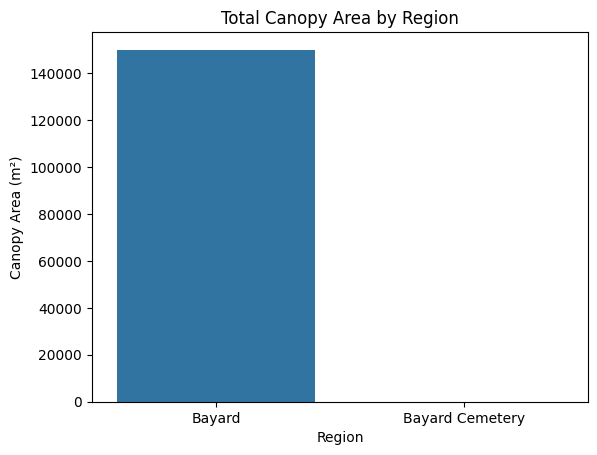

In [24]:
sns.barplot(x='place', y='canopy_area', data=grouped_stats)
plt.title('Total Canopy Area by Region')
plt.xlabel('Region')
plt.ylabel('Canopy Area (m²)')
plt.show()

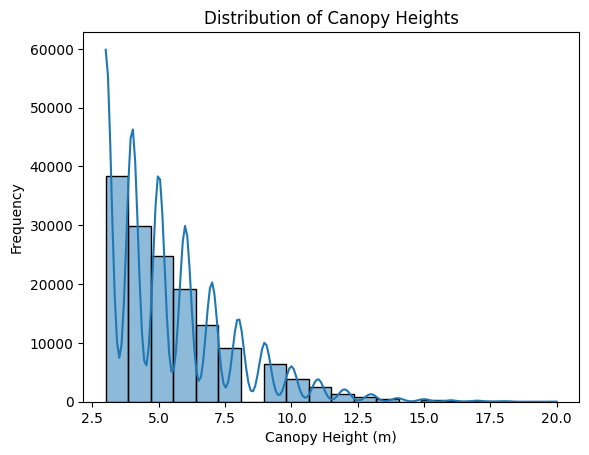

In [25]:
sns.histplot(canopy_heights, bins=20, kde=True)
plt.title('Distribution of Canopy Heights')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.show()


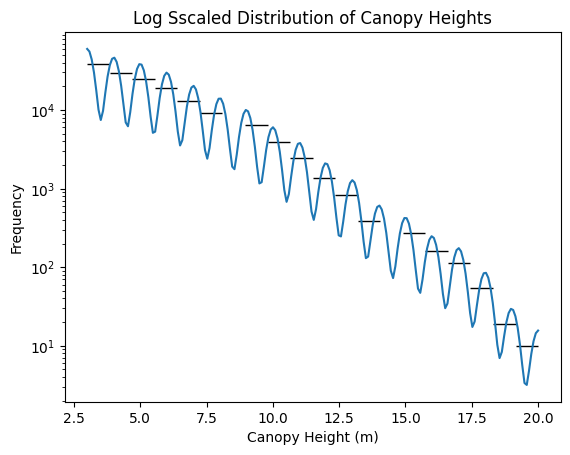

In [26]:
sns.histplot(canopy_heights, bins=20, kde=True, log_scale=(False, True))
plt.title('Log Sscaled Distribution of Canopy Heights')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.show()

In [27]:
total_canopy_area = grouped_stats['canopy_area'].sum()

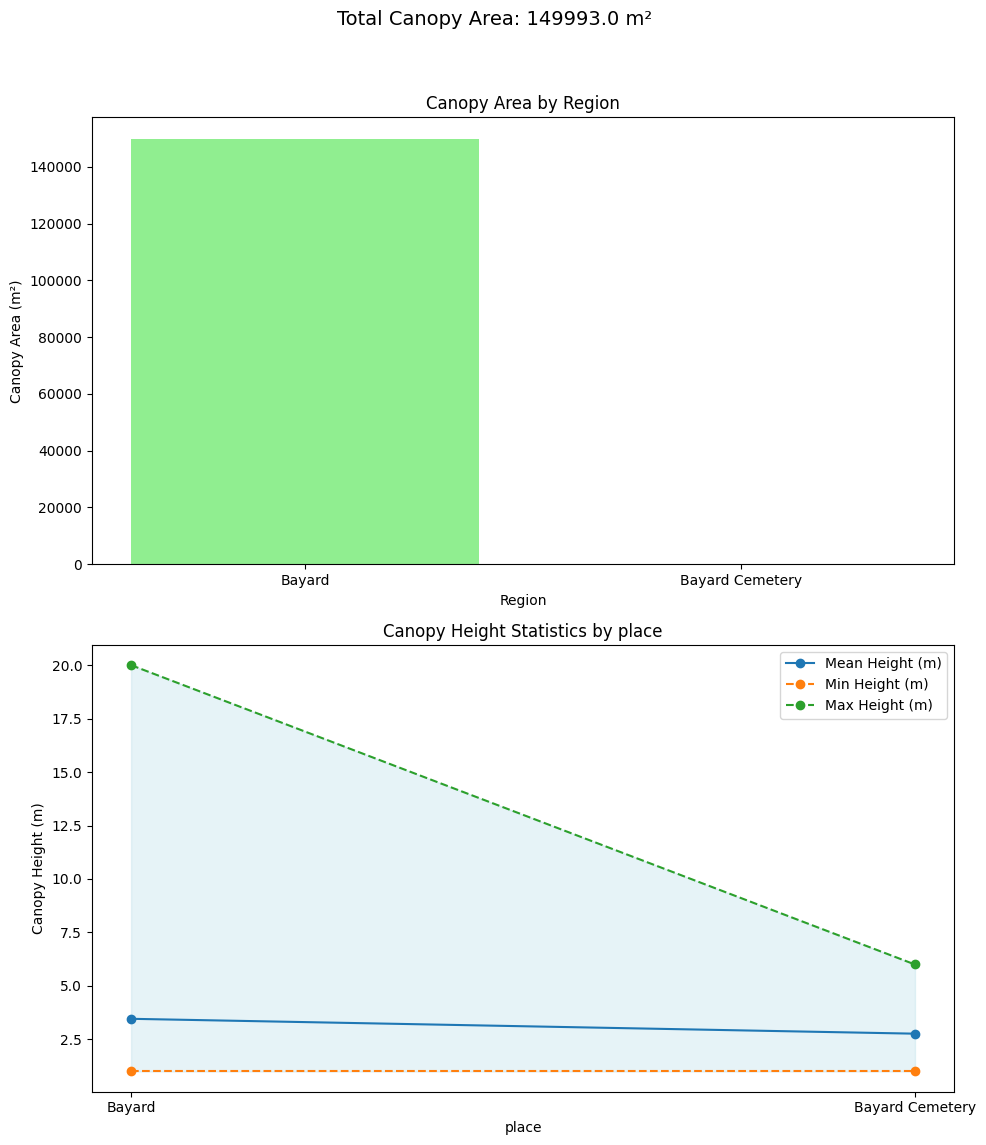

In [28]:
# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# Bar chart for canopy area by place
ax[0].bar(gdf["place"], gdf["canopy_area"], color='lightgreen')
ax[0].set_title("Canopy Area by Region")
ax[0].set_ylabel("Canopy Area (m²)")
ax[0].set_xlabel("Region")
# Line plot for canopy height stats by place
ax[1].plot(gdf["place"], gdf["canopy_mean"], marker='o', label='Mean Height (m)')
ax[1].plot(gdf["place"], gdf["canopy_min"], marker='o', linestyle='--', label='Min Height (m)')
ax[1].plot(gdf["place"], gdf["canopy_max"], marker='o', linestyle='--', label='Max Height (m)')
ax[1].fill_between(gdf["place"], gdf["canopy_min"], gdf["canopy_max"], color='lightblue', alpha=0.3)
ax[1].set_title("Canopy Height Statistics by place")
ax[1].set_ylabel("Canopy Height (m)")
ax[1].set_xlabel("place")
ax[1].legend()

# Display the total canopy area on the plot
fig.suptitle(f"Total Canopy Area: {total_canopy_area} m²", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
# %% Calculate Understory and Overstory Stats for Each Polygon
def calculate_region_understory_overstory_stats(geometry, canopy_raster, mask, transform):
    """Calculate understory and overstory stats for a specific polygon region."""
    # Mask the raster by the geometry
    region_mask = rasterio.features.geometry_mask(
        [geometry], transform=transform, invert=True, out_shape=canopy_raster.shape)
    
    combined_mask = region_mask & mask  # Combine with canopy mask
    
    # Separate understory and overstory
    understory_mask = (canopy_raster > 1) & (canopy_raster <= 3) & combined_mask
    overstory_mask = (canopy_raster > 3) & combined_mask
    
    # Calculate areas
    understory_area = np.sum(understory_mask) * pixel_area
    overstory_area = np.sum(overstory_mask) * pixel_area
    
    # Percentages (relative to the region area)
    region_area = np.sum(region_mask) * pixel_area
    understory_percent = (understory_area / region_area) * 100 if region_area > 0 else 0
    overstory_percent = (overstory_area / region_area) * 100 if region_area > 0 else 0
    
    return {
        'understory_area': understory_area,
        'understory_percent': understory_percent,
        'overstory_area': overstory_area,
        'overstory_percent': overstory_percent
    }

In [30]:
# %% Apply Stats Calculation to Each Region in the GeoDataFrame
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)
    transform = src.transform

    stats = []
    for _, row in gdf.iterrows():
        stats.append(calculate_region_understory_overstory_stats(
            row.geometry, canopy_data, canopy_mask, transform))

In [31]:

# Convert stats to a DataFrame and merge with GeoDataFrame
stats_df = pd.DataFrame(stats)


In [32]:
stats_df

,understory_area,understory_percent,overstory_area,overstory_percent
0,38258.0,1.642143,111709.0,4.794870
1,8.0,0.024855,18.0,0.055923


In [33]:
gdf = pd.concat([gdf, stats_df], axis=1)
gdf

,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,...,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area,understory_area,understory_percent,overstory_area,overstory_percent
0,35,06270,02409799,3506270,1600000US3506270,Bayard,Bayard city,25,C1,N,...,1.0,20.0,3.460358,2.639650,3.0,149967.0,38258.0,1.642143,111709.0,4.794870
1,35,06270,02409799,3506270,1600000US3506270,Bayard,Bayard city,25,C1,N,...,1.0,6.0,2.764706,1.744327,3.0,26.0,8.0,0.024855,18.0,0.055923


In [34]:
# %% Recalculate Canopy Cover Percent
gdf['canopy_cover_percent'] = (
    (gdf['understory_area'] + gdf['overstory_area']) / gdf['area']) * 100

# %% Group by Region and Summarize
summary_stats = gdf.groupby('place').agg({
    'canopy_cover_percent': 'mean',
    'understory_area': 'sum',
    'overstory_area': 'sum',
    'understory_percent': 'mean',
    'overstory_percent': 'mean'
}).reset_index()

# %% Display Results
print(summary_stats)


             place  canopy_cover_percent  understory_area  overstory_area  \
0           Bayard              6.443180          38258.0        111709.0   
1  Bayard Cemetery              0.080856              8.0            18.0   

   understory_percent  overstory_percent  
0            1.642143           4.794870  
1            0.024855           0.055923  


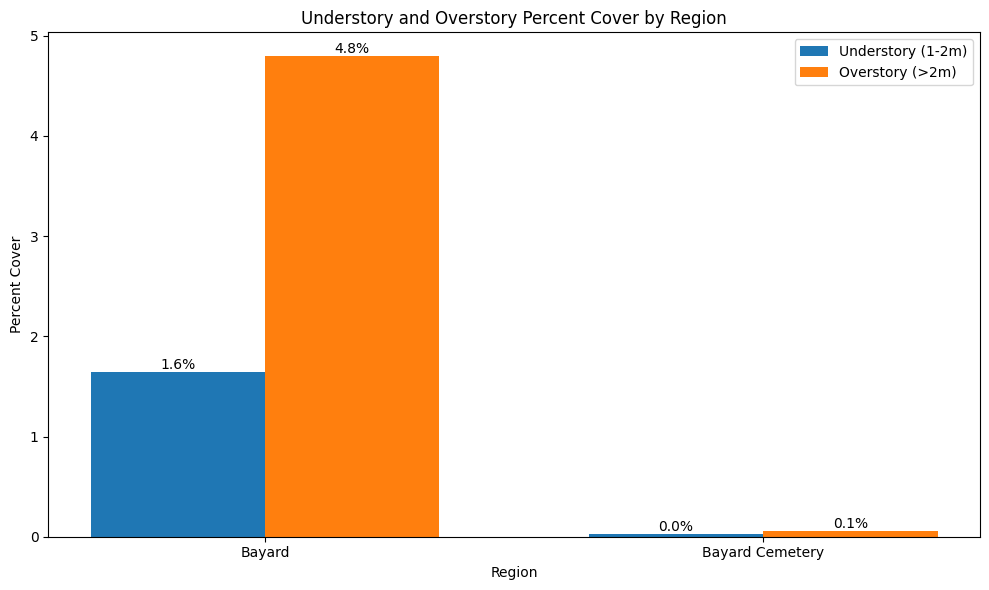

In [35]:

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(summary_stats))

# Create the bars
understory_bars = ax.bar(index, summary_stats['understory_percent'], bar_width, label='Understory (1-2m)')
overstory_bars = ax.bar(index + bar_width, summary_stats['overstory_percent'], bar_width, label='Overstory (>2m)')

# Add annotations
for bar in understory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,  # Position text at center of the bar
        f"{height:.1f}%",  # Format the text
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

for bar in overstory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

# Set plot labels and title
ax.set_title('Understory and Overstory Percent Cover by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Percent Cover')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary_stats['place'])
ax.legend()

plt.tight_layout()
plt.show()
